# 04 — Product Review Summarization with BART

Uses `facebook/bart-large-cnn` to produce structured **Pros / Cons** summaries per `product_id`:
- Concatenates all **positive** reviews for a product → summarised as *Pros*
- Concatenates all **negative** reviews for a product → summarised as *Cons*
- Groups results by `product_id` and saves to parquet

In [8]:
import sys
import os
import glob
import warnings
from typing import List
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import BartForConditionalGeneration, BartTokenizer
from tqdm.auto import tqdm

if torch.cuda.is_available():
    DEVICE = torch.device("cuda"); DEVICE_NAME = "CUDA GPU"
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps"); DEVICE_NAME = "Apple MPS GPU"
else:
    DEVICE = torch.device("cpu"); DEVICE_NAME = "CPU"

print("PyTorch:", torch.__version__)
print(f"Device: {DEVICE_NAME}")

DATA_DIR = os.path.abspath("../data/processed/sentiment")
OUT_DIR  = DATA_DIR

PyTorch: 2.12.1
Device: Apple MPS GPU


## 1. Load Data

Prefer the sentiment-scored parquet (notebook 03 output). Falls back to raw processed parquets with the pre-existing `sentiment_label` column.

In [9]:
SENTIMENT_SCORED = os.path.join(DATA_DIR, "sentiment_scored")
SAMPLE_PER_CATEGORY = 3000

if os.path.isdir(SENTIMENT_SCORED):
    # notebook 03 output — use roberta_label
    parts = glob.glob(f"{SENTIMENT_SCORED}/*.parquet")
    df = pd.concat(
        [pd.read_parquet(p, columns=["product_id", "product_title", "product_category",
                                      "review", "roberta_label"]) for p in parts],
        ignore_index=True
    )
    df = df.rename(columns={"roberta_label": "sentiment"})
    print(f"Loaded sentiment_scored: {len(df):,} rows")
else:
    # fallback: raw processed parquets already have sentiment_label
    parquet_files = sorted(glob.glob(f"{DATA_DIR}/*_processed.parquet"))
    print(f"sentiment_scored not found — loading {len(parquet_files)} raw parquets...")
    frames = []
    for path in parquet_files:
        tmp = pd.read_parquet(
            path,
            columns=["product_id", "product_title", "product_category",
                     "review", "sentiment_label"]
        ).rename(columns={"sentiment_label": "sentiment"})
        frames.append(tmp.sample(min(SAMPLE_PER_CATEGORY, len(tmp)), random_state=42))
    df = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(df):,} rows from raw parquets")

df["sentiment"] = df["sentiment"].str.lower().str.strip()
df = df[df["product_id"].notna() & df["review"].notna()].copy()
df["review"] = df["review"].astype(str).str[:800]

print(f"\nShape: {df.shape}")
print(f"Sentiment counts:\n{df['sentiment'].value_counts()}")
print(f"\nUnique products: {df['product_id'].nunique():,}")

Loaded sentiment_scored: 30,000 rows

Shape: (30000, 5)
Sentiment counts:
sentiment
positive    22298
negative     5201
neutral      2501
Name: count, dtype: int64

Unique products: 24,358


## 2. Load BART Model

Loaded directly via `BartForConditionalGeneration` — the `"summarization"` pipeline task was removed in transformers 5.x.

In [10]:
BART_MODEL = "facebook/bart-large-cnn"

tokenizer = BartTokenizer.from_pretrained(BART_MODEL)
model = BartForConditionalGeneration.from_pretrained(
    BART_MODEL,
    torch_dtype=torch.float16,  # halves memory vs float32
)
model = model.to(DEVICE)
model.eval()

print(f"Model loaded: {BART_MODEL}")
print(f"Running on : {DEVICE_NAME}")

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 
Loading weights: 100%|██████████| 511/511 [00:02<00:00, 232.15it/s]


Model loaded: facebook/bart-large-cnn
Running on : Apple MPS GPU


## 3. Build Per-Product Review Corpus

Group by `product_id`, separate positive and negative reviews, and concatenate into a single text blob for BART.
Only products with **≥ 3 reviews** on each side are summarised (fewer reviews don't benefit from abstractive summarisation).

In [11]:
MIN_REVIEWS          = 3    # min reviews per sentiment side
MAX_REVIEWS_PER_SIDE = 10   # cap to stay within BART's 1024-token limit
MAX_CHARS_PER_REVIEW = 300  # truncate individual reviews before joining

def build_corpus(reviews: pd.Series) -> str:
    return " ".join(r[:MAX_CHARS_PER_REVIEW] for r in reviews.dropna().head(MAX_REVIEWS_PER_SIDE))

positive_df = df[df["sentiment"] == "positive"]
negative_df = df[df["sentiment"] == "negative"]

# Build corpus + count in one safe groupby (index-aligned concat)
pos_text  = positive_df.groupby("product_id")["review"].apply(build_corpus).rename("pos_corpus")
pos_count = positive_df.groupby("product_id")["review"].count().rename("pos_count")
pos_agg   = pd.concat([pos_text, pos_count], axis=1).reset_index()

neg_text  = negative_df.groupby("product_id")["review"].apply(build_corpus).rename("neg_corpus")
neg_count = negative_df.groupby("product_id")["review"].count().rename("neg_count")
neg_agg   = pd.concat([neg_text, neg_count], axis=1).reset_index()

meta = df[["product_id", "product_title", "product_category"]].drop_duplicates("product_id")
product_corpus = (
    meta
    .merge(pos_agg, on="product_id", how="inner")
    .merge(neg_agg, on="product_id", how="inner")
)
product_corpus = product_corpus[
    (product_corpus["pos_count"] >= MIN_REVIEWS) &
    (product_corpus["neg_count"] >= MIN_REVIEWS)
].reset_index(drop=True)

print(f"Products eligible for summarisation: {len(product_corpus):,}")
print(product_corpus[["product_id", "product_title", "pos_count", "neg_count"]].head(5))

Products eligible for summarisation: 34
   product_id                         product_title  pos_count  neg_count
0  B00E8KLWB4  The Secret Society® - Hidden Mystery         35          6
1  B00X3C9EUE                 Make-Up Me: Superstar          3          3
2  B00ZP4XJF4                       AlphaBetty Saga          8          3
3  B004GJDQT8                    Amazon Underground         69          7
4  B00992CF6W                             Minecraft         30          5


## 4. Run BART Summarization

Run BART separately on the positive corpus (→ **pros**) and the negative corpus (→ **cons**) for each product.

In [12]:
def summarize_batch(texts: List[str], min_len: int = 30, max_len: int = 120) -> List[str]:
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        max_length=1024,
        padding=True,
    ).to(DEVICE)

    with torch.no_grad():
        ids = model.generate(
            **inputs,
            min_length=min_len,
            max_length=max_len,
            num_beams=4,
            early_stopping=True,
        )

    return tokenizer.batch_decode(ids, skip_special_tokens=True)


BATCH_SIZE = 8
pros_summaries: List[str] = []
cons_summaries: List[str] = []

pos_texts = product_corpus["pos_corpus"].tolist()
neg_texts = product_corpus["neg_corpus"].tolist()

print("Summarising PROS (positive reviews)...")
for i in tqdm(range(0, len(pos_texts), BATCH_SIZE)):
    pros_summaries.extend(summarize_batch(pos_texts[i : i + BATCH_SIZE]))

print("Summarising CONS (negative reviews)...")
for i in tqdm(range(0, len(neg_texts), BATCH_SIZE)):
    cons_summaries.extend(summarize_batch(neg_texts[i : i + BATCH_SIZE]))

product_corpus["pros"] = pros_summaries
product_corpus["cons"] = cons_summaries

print(f"\nDone — summaries generated for {len(product_corpus):,} products.")

Summarising PROS (positive reviews)...


100%|██████████| 5/5 [00:37<00:00,  7.40s/it]


Summarising CONS (negative reviews)...


100%|██████████| 5/5 [00:32<00:00,  6.50s/it]


Done — summaries generated for 34 products.


## 5. Structured Product Summary Table

In [13]:
summary_df = product_corpus[[
    "product_id",
    "product_title",
    "product_category",
    "pos_count",
    "neg_count",
    "pros",
    "cons",
]].copy()

summary_df["total_reviews"] = summary_df["pos_count"] + summary_df["neg_count"]
summary_df["positive_ratio"] = (summary_df["pos_count"] / summary_df["total_reviews"]).round(3)

# Pretty-print sample
pd.set_option("display.max_colwidth", 120)
print(f"Product summaries: {len(summary_df):,}\n")
summary_df[["product_id", "product_title", "pros", "cons"]].head(5)

Product summaries: 34



,product_id,product_title,pros,cons
0,B00E8KLWB4,The Secret Society® - Hidden Mystery,Love. a great game! good free game.. this is a pretty entertaining little game with some very challenging hidden obj...,"resolution is so poor it is difficult to see things addictive. hard to locate items in amount of time, makes it hard..."
1,B00X3C9EUE,Make-Up Me: Superstar,love it!. it was a really fun game to play and i love to see the looks i can create. some people say that it is a ri...,"great, not perfect. fun app, but slow to load and often shuts down. doesn't work on a kindle users. it keeps freezin..."
2,B00ZP4XJF4,AlphaBetty Saga,fun word game to play and becvome addicted to.. love this game. it makes you think and quickly too. great for brain ...,"i find this game not fun at all, dont waste your time on it. it keeps freezing on me. some levels very hard. needs b..."
3,B004GJDQT8,Amazon Underground,"five stars. i like amazon! great overall, i do all my shopping on amazon because i know i'll get great quality at a ...","i don't think i'll be buying or getting anything for free from amazon on my phone anymore, this app wants way to man..."
4,B00992CF6W,Minecraft,wow. omg get this app its so much fun !!!!!!!!! it costs money but it's the best. this is the best app overall i hav...,"the pocket addition is good, but not as cool as the full version. it's awesome and all but,it crashes what i mean is..."


In [14]:
# Inspect a single product in detail
sample = summary_df.iloc[0]
print("=" * 70)
print(f"Product ID   : {sample['product_id']}")
print(f"Title        : {sample['product_title']}")
print(f"Category     : {sample['product_category']}")
print(f"Reviews      : {sample['total_reviews']} total  "
      f"({sample['pos_count']} positive / {sample['neg_count']} negative)")
print(f"Positive ratio: {sample['positive_ratio']:.1%}")
print()
print("PROS")
print("-" * 70)
print(sample["pros"])
print()
print("CONS")
print("-" * 70)
print(sample["cons"])

Product ID   : B00E8KLWB4
Title        : The Secret Society® - Hidden Mystery
Category     : Mobile_Apps
Reviews      : 41 total  (35 positive / 6 negative)
Positive ratio: 85.4%

PROS
----------------------------------------------------------------------
Love. a great game! good free game.. this is a pretty entertaining little game with some very challenging hidden object scenes. Overall theme good. difficult to see some of the icons to the lower right. theme is good, but i find myself wondering why i am not advancing. worth the time.

CONS
----------------------------------------------------------------------
resolution is so poor it is difficult to see things addictive. hard to locate items in amount of time, makes it hard to advance. confusing. been playing for three days now and still not sure what the point is.


## 6. Summary Statistics by Category

product_category  products_summarised  avg_positive_ratio
     Mobile_Apps                   24            0.720708
       Furniture                    5            0.706800
          Beauty                    1            0.500000
           Books                    4            0.495750


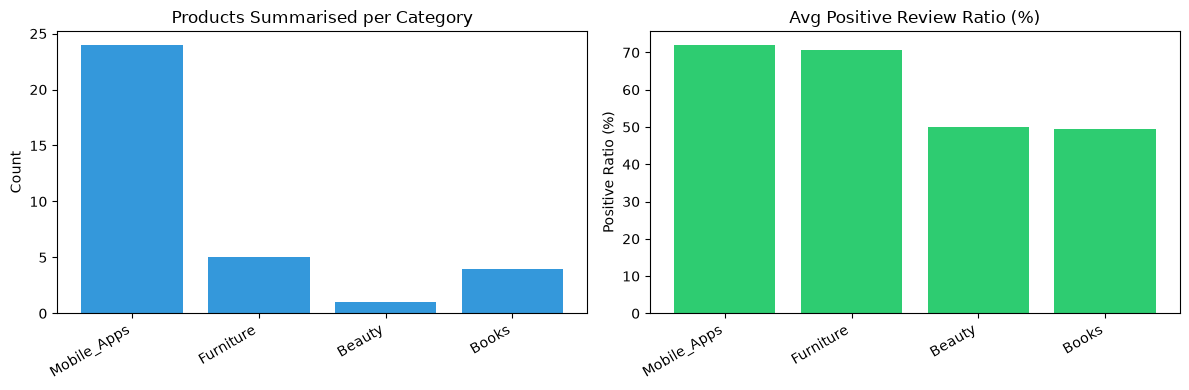

In [15]:
category_stats = (
    summary_df.groupby("product_category")
    .agg(
        products_summarised=("product_id", "count"),
        avg_positive_ratio=("positive_ratio", "mean"),
    )
    .sort_values("avg_positive_ratio", ascending=False)
    .reset_index()
)

print(category_stats.to_string(index=False))

categories = category_stats["product_category"]
x = range(len(categories))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x, category_stats["products_summarised"], color="#3498db")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(categories, rotation=30, ha="right")
axes[0].set_title("Products Summarised per Category")
axes[0].set_ylabel("Count")

axes[1].bar(x, category_stats["avg_positive_ratio"] * 100, color="#2ecc71")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(categories, rotation=30, ha="right")
axes[1].set_title("Avg Positive Review Ratio (%)")
axes[1].set_ylabel("Positive Ratio (%)")

plt.tight_layout()
plt.show()

## 7. Save Results

In [16]:
OUT_PATH = os.path.join(OUT_DIR, "product_summaries.parquet")
summary_df.to_parquet(OUT_PATH, index=False)
print(f"Saved {len(summary_df):,} product summaries → {OUT_PATH}")
print("\nSchema:")
print(summary_df.dtypes)
print("\nSample output:")
print(summary_df[["product_id", "product_category", "pros", "cons"]].head(3).to_string(index=False))

Saved 34 product summaries → /Users/varsha/Documents/GitHub/product-review-intelligence-platform/data/processed/sentiment/product_summaries.parquet

Schema:
product_id              str
product_title           str
product_category        str
pos_count             int64
neg_count             int64
pros                    str
cons                    str
total_reviews         int64
positive_ratio      float64
dtype: object

Sample output:
product_id product_category                                                                                                                                                                                                                                                                                                                                          pros                                                                                                                                                                                                        